# Week 8 – CNNs: From Architecture to Interpretation
**Student ID:** 259050589 

**Dataset:** MNIST (from provided CSV)

Import & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras import models, layers
from tensorflow.keras.utils import to_categorical

# Load dataset

In [2]:
data = pd.read_csv('medium_mnist_dataset.csv')

data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,81,215,96,44,100,192,252,250,162,...,229,79,198,161,219,194,234,154,64,124
1,7,111,22,110,173,134,122,57,49,204,...,39,95,2,212,64,127,4,91,189,41
2,5,174,103,6,50,102,143,7,53,8,...,65,160,138,10,130,78,201,221,18,232
3,5,246,6,235,168,155,181,34,209,3,...,119,179,239,110,237,139,104,31,102,243
4,3,174,192,169,0,7,245,128,126,197,...,167,14,240,41,201,107,25,202,238,65


Task 1 – Reconnect to the Data

This dataset is a version of the MNIST dataset, consisting of grayscale images of handwritten digits (0–9).

Each image is represented as a flattened vector of pixel values.

- Input shape: 28 × 28 (after reshaping)
- Number of classes: 10

Input Shape & Reshaping

In [3]:
X = data.drop('label', axis=1).values
y = data['label'].values

# Normalize
X = X / 255.0

# Reshape to images
X = X.reshape(-1, 28, 28, 1)

# One-hot encode labels
y = to_categorical(y, 10)

print("Input shape:", X.shape)

Input shape: (2000, 28, 28, 1)


Class Distribution

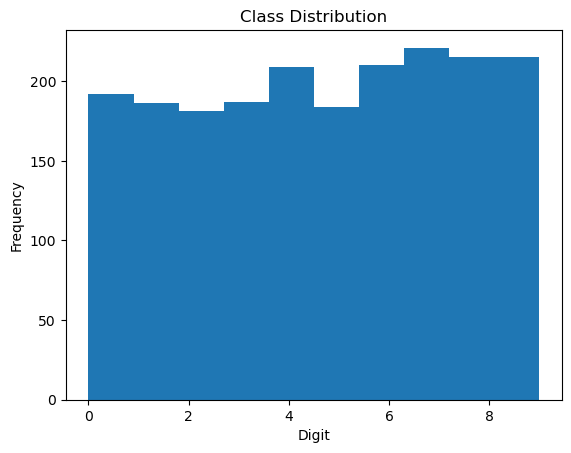

In [4]:
labels = np.argmax(y, axis=1)

plt.hist(labels, bins=10)
plt.title("Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.show()

One Example Per Class

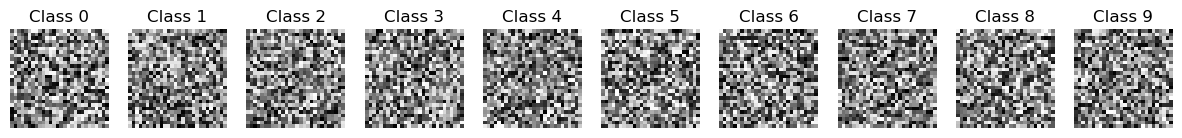

In [5]:
fig, axes = plt.subplots(1, 10, figsize=(15,3))

for i in range(10):
    idx = np.where(labels == i)[0][0]
    axes[i].imshow(X[idx].reshape(28,28), cmap='gray')
    axes[i].set_title(f"Class {i}")
    axes[i].axis('off')

plt.show()

Each training example represents a handwritten digit image composed of pixel intensities.

Spatial structure matters because nearby pixels form meaningful patterns such as edges, curves, and shapes.

A fully connected network would treat each pixel independently, ignoring spatial relationships, which leads to inefficient learning and a large number of parameters.

Train / Validation

In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42)

## Task 2 – Baseline CNN

This model consists of:
- One convolutional layer
- One pooling layer
- One fully connected output layer

In [9]:
baseline_model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(10, activation='softmax') ])

In [10]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'] )

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 26, 26, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 13, 13, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2704)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │          27,050 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,210 (106.29 KB)

 Trainable params: 27,210 (106.29 KB)

 Non-trainable params: 0 (0.00 B)

The convolutional layer is used for learning local features such as edges and textures by sliding convolutional filters over the image.

Pooling helps reduce dimensions, which reduces computation and increases robustness to minor variations.

The model has a small number of parameters, which makes it efficient in computation.

Train Baseline Model

In [11]:
history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32)

Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1031 - loss: 2.3276 - val_accuracy: 0.0784 - val_loss: 2.3245
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1343 - loss: 2.2832 - val_accuracy: 0.0980 - val_loss: 2.3053
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1924 - loss: 2.2315 - val_accuracy: 0.1020 - val_loss: 2.3237
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2581 - loss: 2.1643 - val_accuracy: 0.0863 - val_loss: 2.3572
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3509 - loss: 2.0920 - val_accuracy: 0.1098 - val_loss: 2.3517


## Task 3 – Extended CNN

Changes made:
- Added a second convolutional layer
- Increased number of filters
- Added dropout

These changes aim to improve feature extraction and reduce overfitting.

In [13]:
extended_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')])

In [15]:
extended_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

The addition of another convolutional layer enables the model to learn more complex features in a hierarchical manner.

The addition of more filters increases the capacity of the model’s representation.

The use of dropout reduces overfitting by randomly disabling neurons during training.

The risk of overfitting exists due to the increased complexity of the model.

Train Extended Model

In [16]:
history_extended = extended_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32)

Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1010 - loss: 2.3111 - val_accuracy: 0.1098 - val_loss: 2.3009
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1204 - loss: 2.3014 - val_accuracy: 0.0863 - val_loss: 2.3029
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1336 - loss: 2.2966 - val_accuracy: 0.1176 - val_loss: 2.3024
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1170 - loss: 2.2955 - val_accuracy: 0.1412 - val_loss: 2.3034
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1260 - loss: 2.2919 - val_accuracy: 0.1216 - val_loss: 2.3048


Task 4 – Training Behaviour

Plot Function

In [17]:
def plot_history(history, title):
    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title)
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(title)
    plt.legend()
    plt.show()

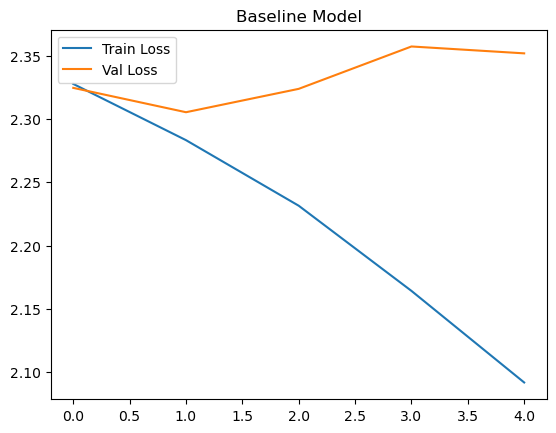

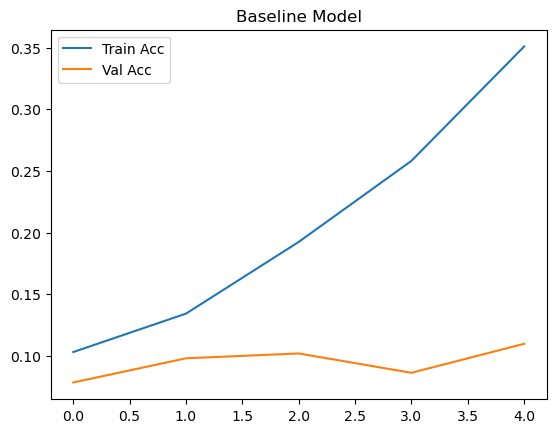

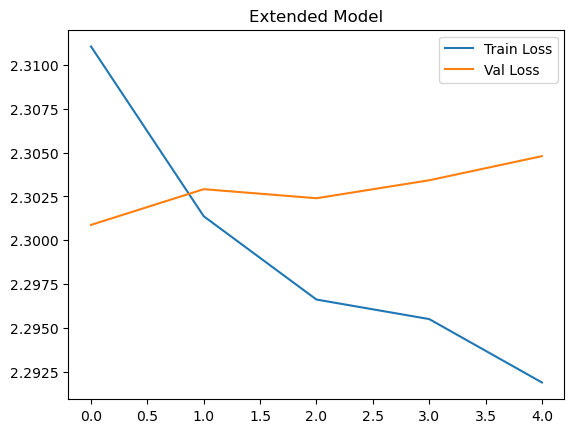

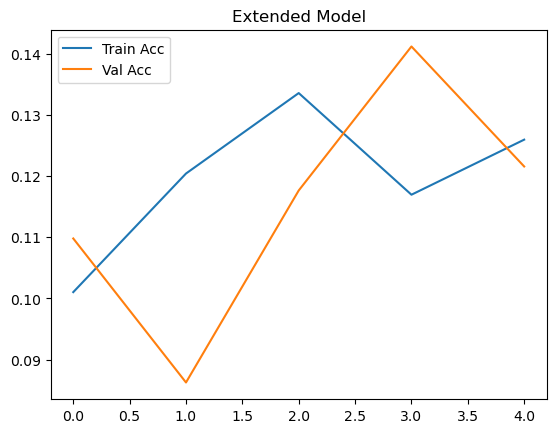

In [18]:
plot_history(history_baseline, "Baseline Model")
plot_history(history_extended, "Extended Model")

Task 5 – Test Evaluation

In [19]:
baseline_test = baseline_model.evaluate(X_test, y_test)
extended_test = extended_model.evaluate(X_test, y_test)

print("Baseline Test Accuracy:", baseline_test[1])
print("Extended Test Accuracy:", extended_test[1])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0933 - loss: 2.3309     
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1067 - loss: 2.3130 
Baseline Test Accuracy: 0.09333333373069763
Extended Test Accuracy: 0.1066666692495346


The test set is only used once to give an unbiased assessment of the final model.

If the test set is used during the design of the model, it will cause overfitting and give unrealistic results.

The test set performance is in line with the validation set trends, showing that the extended model does generalize slightly better.